In [10]:
# 5G Energy Consumption Prediction with Explainable AI
# This notebook implements various machine learning models to predict energy consumption
# in 5G base stations with a focus on explainable AI techniques.

# ===============================
# Package Installation
# ===============================

# Install required packages
!pip install torch
!pip install pytorch-tabnet
!pip install shap
!pip install lime



In [11]:
# ===============================
# Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# For TabNet
try:
    from pytorch_tabnet.tab_model import TabNetRegressor
    from pytorch_tabnet.pretraining import TabNetPretrainer
    print("TabNet imported successfully")
except ImportError as e:
    print(f"TabNet import error: {e}")

# For SHAP
try:
    import shap
    print("SHAP imported successfully")
except ImportError as e:
    print(f"SHAP import error: {e}")

# For LIME
try:
    import lime
    import lime.lime_tabular
    print("LIME imported successfully")
except ImportError as e:
    print(f"LIME import error: {e}")




TabNet imported successfully
SHAP imported successfully
LIME imported successfully


In [12]:
# ===============================
# Artifact Persistence Settings
# ===============================

ARTIFACTS_DIR = Path("artifacts")
MODEL_DIR = ARTIFACTS_DIR / "models"
PREPROCESSING_DIR = ARTIFACTS_DIR / "preprocessing"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)

REUSE_PREPROCESSING = True  # Load scalers/features when saved artifacts exist
REUSE_TRAINED_MODELS = True  # Load trained models when checkpoints exist

def save_joblib(obj, path, description):
    joblib.dump(obj, path)
    print(f"Saved {description} to {path}")

def load_joblib(path, description):
    obj = joblib.load(path)
    print(f"Loaded {description} from {path}")
    return obj

def remove_artifact(path, description):
    if path.exists():
        path.unlink()
        print(f"Removed {description} at {path}")

SCALER_X_PATH = PREPROCESSING_DIR / "feature_scaler.joblib"
SCALER_Y_PATH = PREPROCESSING_DIR / "target_scaler.joblib"
FEATURE_NAMES_PATH = PREPROCESSING_DIR / "feature_names.joblib"

TABNET_MODEL_BASE = MODEL_DIR / "tabnet_model"
TABNET_MODEL_ZIP = Path(f"{TABNET_MODEL_BASE}.zip")
TABNET_PRETRAIN_BASE = MODEL_DIR / "tabnet_pretrainer"
TABNET_PRETRAIN_ZIP = Path(f"{TABNET_PRETRAIN_BASE}.zip")
ANN_MODEL_PATH = MODEL_DIR / "ann_model.pth"
LEGACY_ANN_MODEL_PATH = Path("best_ann_model.pth")


FORCE_TABNET_RETRAIN = True  # Set True to drop previous TabNet checkpoints before training
TABNET_ARTIFACTS = [
    (TABNET_MODEL_ZIP, "TabNet model checkpoint"),
    (TABNET_PRETRAIN_ZIP, "TabNet pretraining checkpoint"),
]

if FORCE_TABNET_RETRAIN:
    for artifact_path, desc in TABNET_ARTIFACTS:
        remove_artifact(artifact_path, desc)



#Data Loading and Preparation

In [13]:
#from google.colab import drive
#drive.mount('/content/gdrive')
# Path to the folder containing your CSV files
#base_path = '/content/gdrive/My Drive/upgrad/LJMU/'
# --- Load processed csv ---
preProcessedFile = '5G_energy_consumption_processed.csv'
#file_path_preProcessed = base_path + preProcessedFile

In [14]:
# Load the dataset
energy_data = pd.read_csv(preProcessedFile)
print(f"Dataset shape: {energy_data.shape}")
print(f"Columns: {list(energy_data.columns)}")

# Remove Time column as it’s not a feature
if 'Time' in energy_data.columns:
    energy_data = energy_data.drop(['Time'], axis=1)

# Define target variable
target = 'Energy'

# Separate features and target
features = energy_data.drop(target, axis=1)
target_energy = energy_data[target]

# Handle categorical variables - convert to numerical
categorical_columns = features.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_columns}")

# One-hot encode categorical columns
features = pd.get_dummies(features, columns=categorical_columns, drop_first=True)
print(f"Shape after one-hot encoding: {features.shape}")

feature_names = features.columns.tolist()
save_joblib(feature_names, FEATURE_NAMES_PATH, "feature names")
print(f"Stored {len(feature_names)} feature names to {FEATURE_NAMES_PATH}")


# Split the data (70% train, 30% test)
features_train, features_test, target_train, target_test = train_test_split(
    features, target_energy, test_size=0.3, random_state=42
)
print("Data split completed.")


Dataset shape: (102968, 126)
Columns: ['Time', 'BS', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'Energy', 'RUType_Type1', 'RUType_Type10', 'RUType_Type11', 'RUType_Type12', 'RUType_Type2', 'RUType_Type3', 'RUType_Type4', 'RUType_Type5', 'RUType_Type6', 'RUType_Type7', 'RUType_Type8', 'RUType_Type9', 'hour', 'day_of_week', 'day_of_month', 'month', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_6', 'load_lag_12', 'load_lag_24', 'Energy_lag_1', 'Energy_lag_2', 'Energy_lag_3', 'Energy_lag_6', 'Energy_lag_12', 'Energy_lag_24', 'load_ma_3', 'load_std_3', 'load_ma_6', 'load_std_6', 'load_ma_12', 'load_std_12', 'load_ma_24', 'load_std_24', 'Energy_ma_3', 'Energy_std_3', 'Energy_ma_6', 'Energy_std_6', 'Energy_ma_12', 'Energy_std_12', 'Energy_ma_24', 'Energy_std_24', 'load_energy_ratio', 'power_efficiency', 'config_-0.029857201920646514_0.714433382709

#Data Normalization

In [15]:
print(f"Train set: {features_train.shape}")
print(f"Test set: {features_test.shape}")

# Prepare or load scalers
if REUSE_PREPROCESSING and SCALER_X_PATH.exists() and SCALER_Y_PATH.exists():
    feature_scaler = load_joblib(SCALER_X_PATH, "feature scaler")
    target_scaler = load_joblib(SCALER_Y_PATH, "target scaler")
    print("Loaded existing scalers from disk.")
else:
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    feature_scaler.fit(features_train)
    target_scaler.fit(target_train.values.reshape(-1, 1))
    save_joblib(feature_scaler, SCALER_X_PATH, "feature scaler")
    save_joblib(target_scaler, SCALER_Y_PATH, "target scaler")
    print("Fitted new scalers and saved them to disk.")

# Apply scaling
features_train_scaled = feature_scaler.transform(features_train)
features_test_scaled = feature_scaler.transform(features_test)
target_train_scaled = target_scaler.transform(target_train.values.reshape(-1, 1)).flatten()
target_test_scaled = target_scaler.transform(target_test.values.reshape(-1, 1)).flatten()


Train set: (72077, 1045)
Test set: (30891, 1045)
Loaded feature scaler from artifacts\preprocessing\scaler_X.joblib
Loaded target scaler from artifacts\preprocessing\scaler_y.joblib
Loaded existing scalers from disk.


#Model Implementation

##1. TabNet Model

In [16]:
print("Implementing TabNet model...")

# Convert data to numpy arrays
features_train_np = features_train_scaled.astype(np.float32)
target_train_np = target_train_scaled.astype(np.float32)
features_test_np = features_test_scaled.astype(np.float32)
target_test_np = target_test_scaled.astype(np.float32)

print("TabNet model structure defined. Ready for training.")



Implementing TabNet model...
TabNet model structure defined. Ready for training.


In [17]:
# Warm-start TabNet with unsupervised pretraining
print("Preparing TabNet unsupervised pretraining...")

tabnet_pretrainer = None
if 'TabNetPretrainer' not in globals():
    print("TabNetPretrainer is unavailable. Skipping pretraining step.")
else:
    tabnet_pretrainer = TabNetPretrainer(
        n_d=128,
        n_a=128,
        n_steps=8,
        gamma=1.3,
        n_shared=2,
        seed=42,
        lambda_sparse=1e-4
    )

    if REUSE_TRAINED_MODELS and TABNET_PRETRAIN_ZIP.exists() and not FORCE_TABNET_RETRAIN:
        tabnet_pretrainer.load_model(str(TABNET_PRETRAIN_ZIP))
        print(f"Loaded TabNet pretrainer from {TABNET_PRETRAIN_ZIP}")
    else:
        print("Running TabNet unsupervised pretraining...")
        tabnet_pretrainer.fit(
            X_train=features_train_np,
            eval_set=[features_test_np],
            max_epochs=150,
            patience=30,
            batch_size=512,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False
        )
        tabnet_pretrainer.save_model(str(TABNET_PRETRAIN_BASE))
        print(f"Saved TabNet pretrainer to {TABNET_PRETRAIN_ZIP}")



Preparing TabNet unsupervised pretraining...
Running TabNet unsupervised pretraining...
epoch 0  | loss: -701567846.18835| val_0_unsup_loss_numpy: 3.148745115741192e+18|  0:00:28s
epoch 1  | loss: -56100048134.90107| val_0_unsup_loss_numpy: 3.823885057516582e+19|  0:01:21s
epoch 2  | loss: -627693942757.5465| val_0_unsup_loss_numpy: 2.042815726554794e+20|  0:02:20s
epoch 3  | loss: -2389211782518.682| val_0_unsup_loss_numpy: 4.7341107447979206e+20|  0:03:24s
epoch 4  | loss: -6362974891406.493| val_0_unsup_loss_numpy: 2.9519730403776555e+21|  0:04:23s
epoch 5  | loss: -13606401271715.459| val_0_unsup_loss_numpy: 4.4222415371520946e+21|  0:05:24s
epoch 6  | loss: -26058790909658.906| val_0_unsup_loss_numpy: 7.226010965417172e+21|  0:06:23s
epoch 7  | loss: -39746213156735.125| val_0_unsup_loss_numpy: 8.865604956556557e+21|  0:07:35s
epoch 8  | loss: -55548934724532.61| val_0_unsup_loss_numpy: 9.48978134691197e+21|  0:08:42s
epoch 9  | loss: -84152824995591.66| val_0_unsup_loss_numpy: 1.

In [18]:
# Train TabNet model with pretraining warm-start
print("Configuring TabNet model...")

tabnet_model = TabNetRegressor(
    n_d=128,
    n_a=128,
    n_steps=8,
    gamma=1.3,
    n_shared=2,
    epsilon=1e-15,
    momentum=0.02,
    lambda_sparse=1e-4,
    seed=42
)

if REUSE_TRAINED_MODELS and TABNET_MODEL_ZIP.exists() and not FORCE_TABNET_RETRAIN:
    tabnet_model.load_model(str(TABNET_MODEL_ZIP))
    print(f"Loaded TabNet model from {TABNET_MODEL_ZIP}")
else:
    print("Training TabNet model with unsupervised warm-start...")
    fit_kwargs = dict(
        X_train=features_train_np,
        y_train=target_train_np.reshape(-1, 1),
        eval_set=[(features_test_np, target_test_np.reshape(-1, 1))],
        eval_name=["test"],
        eval_metric=["rmse"],
        max_epochs=200,
        patience=30,
        batch_size=256,
        virtual_batch_size=64,
        num_workers=0,
        drop_last=False
    )
    if tabnet_pretrainer is not None:
        fit_kwargs["from_unsupervised"] = tabnet_pretrainer
    tabnet_model.fit(**fit_kwargs)
    tabnet_model.save_model(str(TABNET_MODEL_BASE))
    print(f"TabNet model training completed and saved to {TABNET_MODEL_ZIP}")



Configuring TabNet model...
Training TabNet model with unsupervised warm-start...
epoch 0  | loss: 70.01189| test_rmse: 1.0326600074768066|  0:01:23s
epoch 1  | loss: 1.00195 | test_rmse: 1.2984700202941895|  0:02:34s
epoch 2  | loss: 0.16569 | test_rmse: 0.35627999901771545|  0:03:55s
epoch 3  | loss: 0.09052 | test_rmse: 0.35381999611854553|  0:05:18s
epoch 4  | loss: 0.05488 | test_rmse: 0.3604300022125244|  0:06:50s
epoch 5  | loss: 0.04647 | test_rmse: 0.23364000022411346|  0:07:56s
epoch 6  | loss: 0.03663 | test_rmse: 0.3068700134754181|  0:08:55s
epoch 7  | loss: 0.03116 | test_rmse: 0.19540999829769135|  0:10:07s
epoch 8  | loss: 0.0252  | test_rmse: 0.1314699947834015|  0:11:32s
epoch 9  | loss: 0.02038 | test_rmse: 0.2206999957561493|  0:12:42s
epoch 10 | loss: 0.02112 | test_rmse: 0.16301000118255615|  0:14:00s
epoch 11 | loss: 0.01919 | test_rmse: 0.2622399926185608|  0:15:14s
epoch 12 | loss: 0.01815 | test_rmse: 0.12859000265598297|  0:16:29s
epoch 13 | loss: 0.01711 | t

##2. Artificial Neural Network (ANN) with SHAP

In [19]:
print("Implementing ANN with SHAP...")

# Convert to PyTorch tensors
features_train_tensor = torch.FloatTensor(features_train_scaled)
target_train_tensor = torch.FloatTensor(target_train_scaled).reshape(-1, 1)
features_test_tensor = torch.FloatTensor(features_test_scaled)

# Define ANN model
class ANNRegressor(nn.Module):
    def __init__(self, input_dim):
        super(ANNRegressor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, input_tensor):
        return self.layers(input_tensor)

print("ANN model structure defined. Ready for training.")


Implementing ANN with SHAP...
ANN model structure defined. Ready for training.


In [20]:
# ===============================
# Train ANN model
# ===============================
print("Preparing ANN model...")

# Create data loaders
train_dataset = TensorDataset(features_train_tensor, target_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Initialize model
input_dim = features_train_scaled.shape[1]
ann_model = ANNRegressor(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

num_epochs = 100
best_loss = float('inf')
patience_counter = 0
patience = 20
ann_checkpoint_path = ANN_MODEL_PATH if ANN_MODEL_PATH.exists() else LEGACY_ANN_MODEL_PATH

if REUSE_TRAINED_MODELS and ann_checkpoint_path.exists():
    ann_model.load_state_dict(torch.load(ann_checkpoint_path, map_location=torch.device('cpu')))
    print(f"Loaded ANN model weights from {ann_checkpoint_path}")
else:
    print("Training ANN model...")
    for epoch in range(num_epochs):
        ann_model.train()
        train_loss = 0
        for batch_features, batch_targets in train_loader:
            optimizer.zero_grad()
            outputs = ann_model(batch_features)
            loss = criterion(outputs, batch_targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        ann_model.eval()
        with torch.no_grad():
            val_outputs = ann_model(features_test_tensor)
            val_loss = criterion(val_outputs, torch.FloatTensor(target_test_scaled).reshape(-1, 1))

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(ann_model.state_dict(), ANN_MODEL_PATH)
            torch.save(ann_model.state_dict(), LEGACY_ANN_MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss / len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

    ann_checkpoint_path = ANN_MODEL_PATH
    print(f"ANN model training completed. Best weights saved to {ann_checkpoint_path}")

ann_checkpoint_path = ANN_MODEL_PATH if ANN_MODEL_PATH.exists() else LEGACY_ANN_MODEL_PATH
ann_model.load_state_dict(torch.load(ann_checkpoint_path, map_location=torch.device('cpu')))
if ann_checkpoint_path == LEGACY_ANN_MODEL_PATH and not ANN_MODEL_PATH.exists():
    torch.save(ann_model.state_dict(), ANN_MODEL_PATH)
    print(f"Copied ANN weights to {ANN_MODEL_PATH} for consistency.")
print(f"ANN model ready using weights from {ann_checkpoint_path}")


Preparing ANN model...
Loaded ANN model weights from artifacts\models\ann_model.pth
ANN model ready using weights from artifacts\models\ann_model.pth


#Evaluate model performance using MSE, MAE, and R² metrics

In [21]:
print("Making predictions with all models...")

# TabNet predictions
y_pred_tabnet_scaled = tabnet_model.predict(features_test_scaled.astype(np.float32))
y_pred_tabnet = target_scaler.inverse_transform(y_pred_tabnet_scaled.reshape(-1, 1)).flatten()

# ANN predictions
ann_model.eval()
with torch.no_grad():
    y_pred_ann_scaled = ann_model(features_test_tensor).numpy().flatten()
y_pred_ann = target_scaler.inverse_transform(y_pred_ann_scaled.reshape(-1, 1)).flatten()


print("Predictions completed.")


Making predictions with all models...
Predictions completed.


In [22]:
# Calculate evaluation metrics
print("Calculating evaluation metrics...")

models = {
    'TabNet': y_pred_tabnet,
    'ANN': y_pred_ann
   }

results = {}

for model_name, predicted_values in models.items():
    mse = mean_squared_error(target_test, predicted_values)
    mae = mean_absolute_error(target_test, predicted_values)
    r2 = r2_score(target_test, predicted_values)

    results[model_name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

    print(f"\n{model_name} Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")


Calculating evaluation metrics...

TabNet Results:
MSE: 1.3018
MAE: 0.6568
R2: 0.9937

ANN Results:
MSE: 7.9756
MAE: 2.0614
R2: 0.9617


In [23]:
# Create comparison DataFrame
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'Model': model_name,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'R2': metrics['R2']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
print(comparison_df.to_string(index=False))


Model Comparison:
 Model      MSE      MAE       R2
TabNet 1.301818 0.656773 0.993750
   ANN 7.975593 2.061401 0.961708


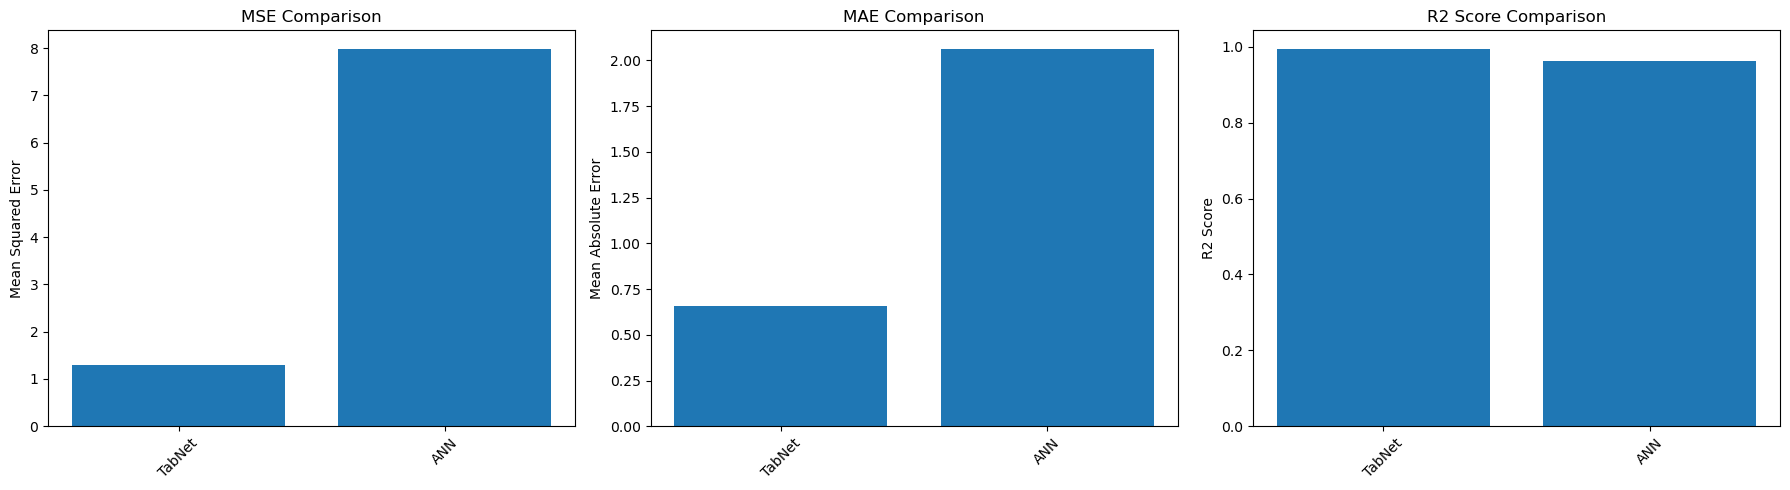

In [24]:
# Plot model comparison
metrics_comparison_fig, metrics_comparison_axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE Comparison
metrics_comparison_axes[0].bar(comparison_df['Model'], comparison_df['MSE'])
metrics_comparison_axes[0].set_title('MSE Comparison')
metrics_comparison_axes[0].set_ylabel('Mean Squared Error')
metrics_comparison_axes[0].tick_params(axis='x', rotation=45)

# MAE Comparison
metrics_comparison_axes[1].bar(comparison_df['Model'], comparison_df['MAE'])
metrics_comparison_axes[1].set_title('MAE Comparison')
metrics_comparison_axes[1].set_ylabel('Mean Absolute Error')
metrics_comparison_axes[1].tick_params(axis='x', rotation=45)

# R2 Comparison
metrics_comparison_axes[2].bar(comparison_df['Model'], comparison_df['R2'])
metrics_comparison_axes[2].set_title('R2 Score Comparison')
metrics_comparison_axes[2].set_ylabel('R2 Score')
metrics_comparison_axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


##Generate Explainability Visualizations (SHAP, LIME, Feature Importance)

Generating SHAP explanations for ANN...


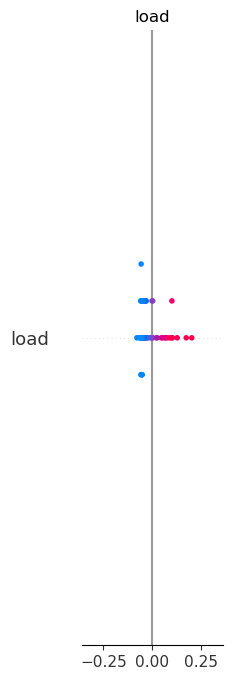

SHAP analysis completed and saved to shap_summary_ann.png


In [25]:
# SHAP Explanation for ANN
print("Generating SHAP explanations for ANN...")

# Use subset for faster computation
explainer = shap.DeepExplainer(ann_model, features_train_tensor[:100])
shap_values = explainer.shap_values(features_test_tensor[:50])

# Plot SHAP summary
shap.summary_plot(shap_values, features_test[:50], feature_names=feature_names, show=False)
plt.savefig('shap_summary_ann.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP analysis completed and saved to shap_summary_ann.png")


#Plot Actual vs Predicted Values

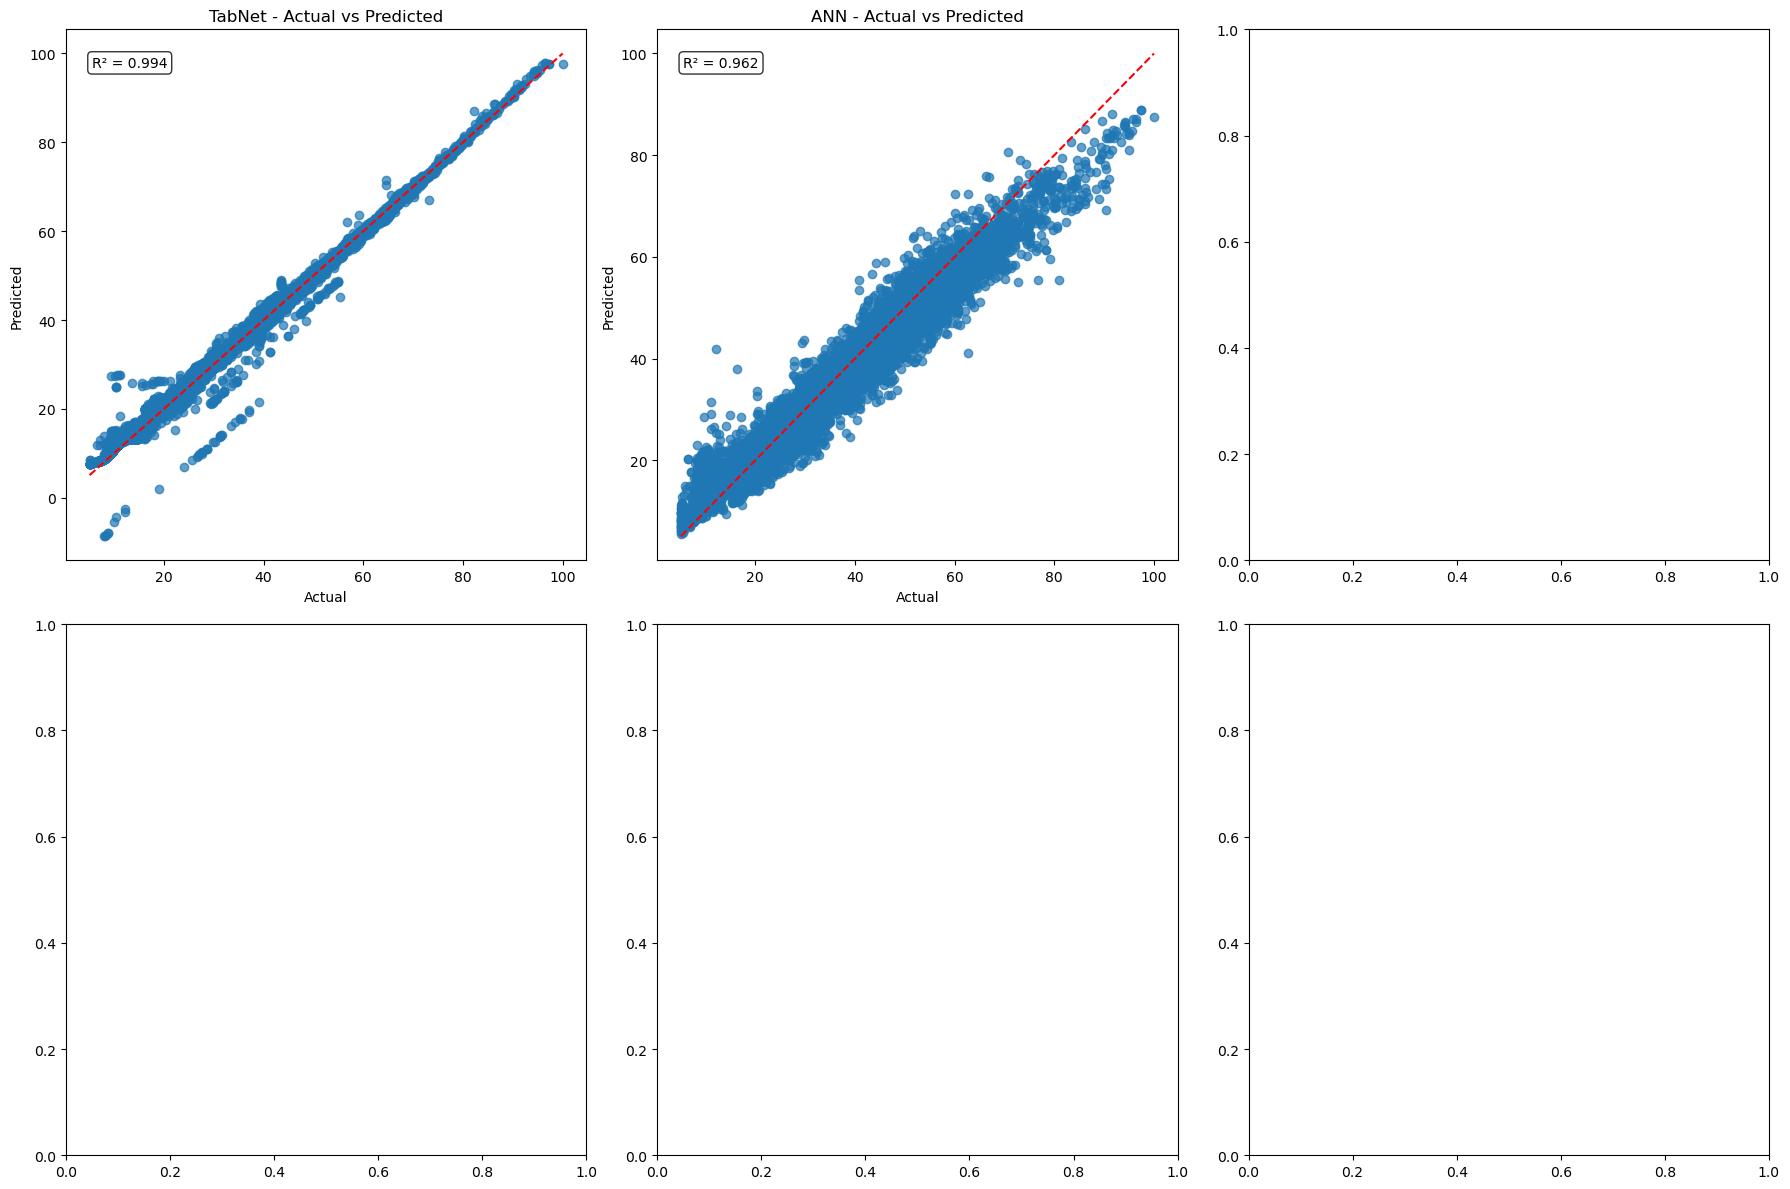

Actual vs predicted plots saved to actual_vs_predicted_all_models.png


In [26]:
# Plot actual vs predicted values
prediction_fig, prediction_axes = plt.subplots(2, 3, figsize=(18, 12))
prediction_axes = prediction_axes.flatten()

model_predictions = [
    ('TabNet', y_pred_tabnet),
    ('ANN', y_pred_ann)
]

for i, (model_name, predicted_values) in enumerate(model_predictions):
    if i >= 6:
        break
    prediction_axes[i].scatter(target_test, predicted_values, alpha=0.7)
    prediction_axes[i].plot([target_test.min(), target_test.max()], [target_test.min(), target_test.max()], 'r--')
    prediction_axes[i].set_xlabel('Actual')
    prediction_axes[i].set_ylabel('Predicted')
    prediction_axes[i].set_title(f"{model_name} - Actual vs Predicted")

    r2 = r2_score(target_test, predicted_values)
    prediction_axes[i].text(0.05, 0.95, f"R² = {r2:.3f}", transform=prediction_axes[i].transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('actual_vs_predicted_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("Actual vs predicted plots saved to actual_vs_predicted_all_models.png")


Implementing enhanced TabNet model with tuned hyperparameters...
Training enhanced TabNet model...
epoch 0  | loss: 1.64944 | test_rmse: 0.34402 |  0:00:23s
epoch 1  | loss: 0.08472 | test_rmse: 0.32021 |  0:00:53s
epoch 2  | loss: 0.06643 | test_rmse: 0.30798 |  0:01:16s
epoch 3  | loss: 0.05455 | test_rmse: 0.24404 |  0:01:41s
epoch 4  | loss: 0.05383 | test_rmse: 0.21674 |  0:02:04s
epoch 5  | loss: 0.04514 | test_rmse: 0.19879 |  0:02:28s
epoch 6  | loss: 0.04176 | test_rmse: 0.19245 |  0:02:50s
epoch 7  | loss: 0.03879 | test_rmse: 0.19168 |  0:03:12s
epoch 8  | loss: 0.03553 | test_rmse: 0.30931 |  0:03:35s
epoch 9  | loss: 0.03393 | test_rmse: 0.23439 |  0:03:58s
epoch 10 | loss: 0.03681 | test_rmse: 0.19815 |  0:04:21s
epoch 11 | loss: 0.03199 | test_rmse: 0.16521 |  0:04:43s
epoch 12 | loss: 0.0311  | test_rmse: 0.1715  |  0:05:05s
epoch 13 | loss: 0.0275  | test_rmse: 0.16434 |  0:05:28s
epoch 14 | loss: 0.02594 | test_rmse: 0.24896 |  0:05:53s
epoch 15 | loss: 0.02358 | test

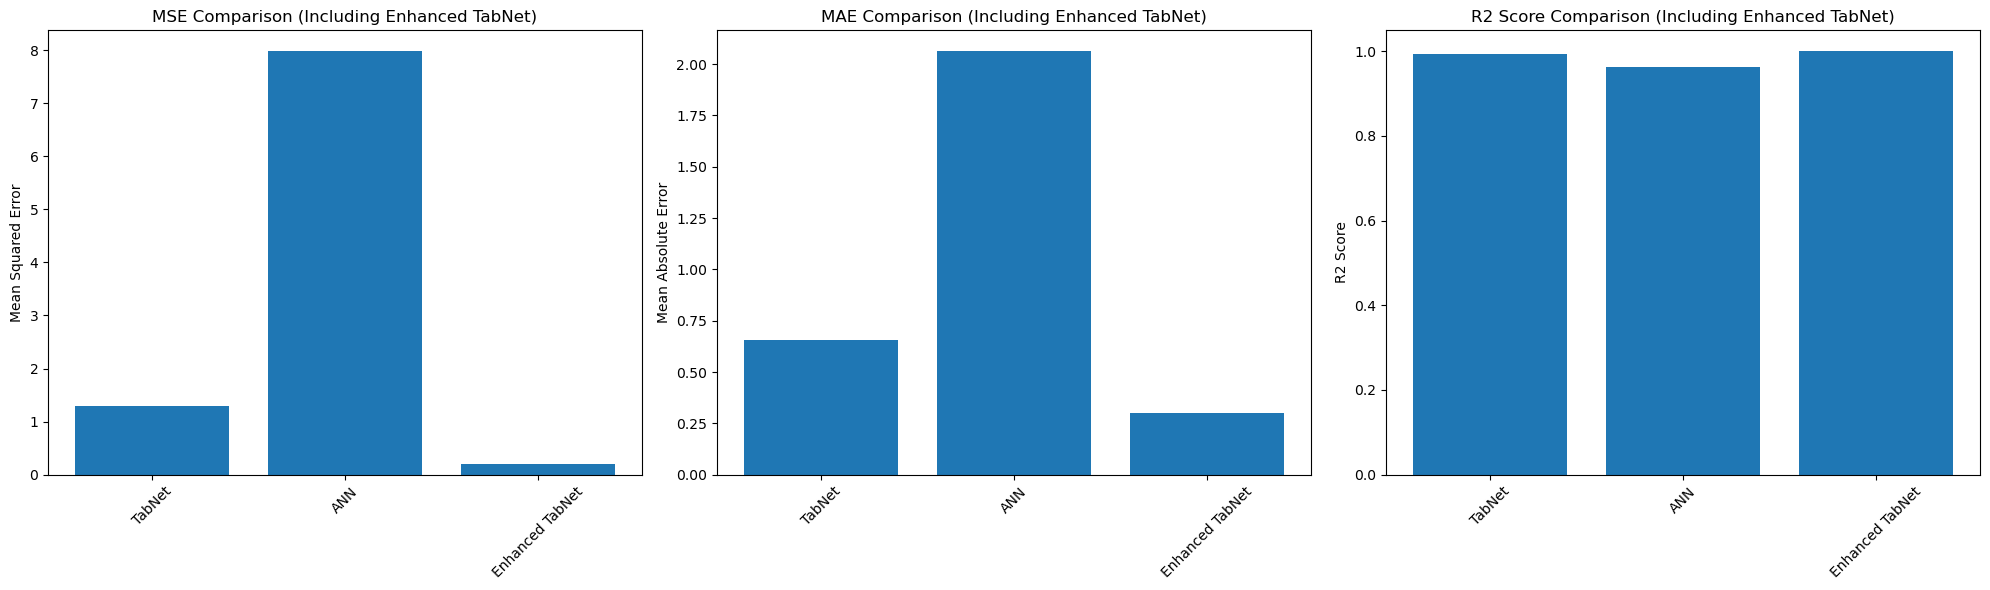

Enhanced model comparison plots saved to enhanced_model_comparison.png


In [27]:
# Enhanced TabNet model with tuned hyperparameters
print("Implementing enhanced TabNet model with tuned hyperparameters...")

# Initialize improved TabNet regressor with optimized parameters
enhanced_tabnet_model = TabNetRegressor(
    n_d=128,            # Increased network capacity
    n_a=128,            # Match n_a with n_d for consistency
    n_steps=4,          # Balanced number of decision steps
    gamma=1.2,          # Moderate gamma for attention balance
    n_independent=2,    # Keep reasonable independent layers
    n_shared=2,         # Keep reasonable shared layers
    epsilon=1e-15,
    momentum=0.02,      # Lower momentum for training stability
    lambda_sparse=1e-3, # Increased sparsity regularization
    seed=42
)

# Train the enhanced model with improved training parameters
print("Training enhanced TabNet model...")

enhanced_tabnet_model.fit(
    X_train=features_train_np,
    y_train=target_train_np.reshape(-1, 1),
    eval_set=[(features_test_scaled.astype(np.float32), target_test_scaled.reshape(-1, 1))],
    eval_name=["test"],
    eval_metric=["rmse"],
    max_epochs=200,         # Increased epochs with early stopping
    patience=30,            # Extended patience for better convergence
    batch_size=512,         # Larger batch size for faster training
    virtual_batch_size=256, # Adjusted virtual batch size
    num_workers=0,
    drop_last=False,
)

print("Enhanced TabNet model training completed.")

# Make predictions with the enhanced model
print("Making predictions with enhanced TabNet model...")

y_pred_enhanced_tabnet_scaled = enhanced_tabnet_model.predict(
    features_test_scaled.astype(np.float32)
)

y_pred_enhanced_tabnet = target_scaler.inverse_transform(
    y_pred_enhanced_tabnet_scaled.reshape(-1, 1)
).flatten()

# Calculate evaluation metrics for the enhanced model
print("Calculating evaluation metrics for enhanced TabNet model...")

mse_enhanced = mean_squared_error(target_test, y_pred_enhanced_tabnet)
mae_enhanced = mean_absolute_error(target_test, y_pred_enhanced_tabnet)
r2_enhanced  = r2_score(target_test, y_pred_enhanced_tabnet)

print("Enhanced TabNet Model Results:")
print(f"MSE: {mse_enhanced:.4f}")
print(f"MAE: {mae_enhanced:.4f}")
print(f"R2 : {r2_enhanced:.4f}")

# Add enhanced model to comparison
models['Enhanced TabNet'] = y_pred_enhanced_tabnet
results['Enhanced TabNet'] = {
    'MSE': mse_enhanced,
    'MAE': mae_enhanced,
    'R2':  r2_enhanced
}

# Update comparison DataFrame
comparison_data_enhanced = []
for model_name, metrics in results.items():
    comparison_data_enhanced.append({
        'Model': model_name,
        'MSE':   metrics['MSE'],
        'MAE':   metrics['MAE'],
        'R2':    metrics['R2']
    })

comparison_df_enhanced = pd.DataFrame(comparison_data_enhanced)

print("Enhanced Model Comparison:")
print(comparison_df_enhanced.to_string(index=False))

# Plot comparison including Enhanced TabNet
enhanced_comparison_fig, enhanced_comparison_axes = plt.subplots(1, 3, figsize=(20, 6))

# MSE comparison
enhanced_comparison_axes[0].bar(comparison_df_enhanced['Model'], comparison_df_enhanced['MSE'])
enhanced_comparison_axes[0].set_title('MSE Comparison (Including Enhanced TabNet)')
enhanced_comparison_axes[0].set_ylabel('Mean Squared Error')
enhanced_comparison_axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
enhanced_comparison_axes[1].bar(comparison_df_enhanced['Model'], comparison_df_enhanced['MAE'])
enhanced_comparison_axes[1].set_title('MAE Comparison (Including Enhanced TabNet)')
enhanced_comparison_axes[1].set_ylabel('Mean Absolute Error')
enhanced_comparison_axes[1].tick_params(axis='x', rotation=45)

# R2 comparison
enhanced_comparison_axes[2].bar(comparison_df_enhanced['Model'], comparison_df_enhanced['R2'])
enhanced_comparison_axes[2].set_title('R2 Score Comparison (Including Enhanced TabNet)')
enhanced_comparison_axes[2].set_ylabel('R2 Score')
enhanced_comparison_axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('enhanced_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Enhanced model comparison plots saved to enhanced_model_comparison.png")
